> **⚠️ SUPERSEDED (2026-07-08).** This raw / single-tail view keeps the frequency / founder-projection confound and is **not** evidence of SV climate purging. The de-trended `s_distribution_by_site.ipynb` is authoritative, and after the full-panel Kf_w / `--unit chrom` regeneration the SV excess-vs-baseline is null there (median +0.0011, 15/31 sites, sign test n.s.).

# Where do SNP / indel / SV selection coefficients actually differ? — frequency-matched shift function

Overlaid histograms made the classes look identical, but (a) they share a broad shape from the
founder projection and (b) SVs are rarer, so the raw comparison is confounded. This figure fixes
both:

**Frequency-matched.** Per site, SNP and indel are resampled to the **SV's p₀ distribution**, so all
classes are compared at the same starting-frequency composition.

**Shift function.** For each percentile τ we plot $Q_{\text{class}}(\tau) - Q_{\text{SNP}}(\tau)$ =
how much more (−) or less (+) negative that class's selection coefficient is than a frequency-matched
SNP at the same rank. **Flat at 0 ⇒ identical to SNPs.** A **dip below 0 at low τ** ⇒ that class has a
heavier *purged* (negative-s) tail. A uniform offset ⇒ a pure location shift. Orange band = 90%
bootstrap CI on the SV shift; if it excludes 0, the SV difference is real at that percentile.
Sites cold→hot.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
npz = np.load(f"{G}/s_dist_by_stratum.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
COL = {"SNP":"#888888","indel":"#0072B2","SV":"#D55E00"}
TAUS = np.linspace(0.05, 0.95, 19)
NBIN, NDRAW, NBOOT = 25, 20000, 300
rng = np.random.default_rng(0)

def match_to(target_p0, src_s, src_p0, rng):
    # resample src_s so its p0 distribution matches target_p0 (bin-stratified, with replacement)
    edges = np.quantile(np.concatenate([target_p0, src_p0]), np.linspace(0,1,NBIN+1)); edges[-1]+=1e-9
    tb = np.digitize(target_p0, edges[1:-1]); sb = np.digitize(src_p0, edges[1:-1])
    props = np.array([(tb==b).mean() for b in range(NBIN)])
    out=[]
    for b in range(NBIN):
        k = int(round(props[b]*NDRAW)); pool = src_s[sb==b]
        if k>0 and pool.size>0: out.append(rng.choice(pool, k, replace=True))
    return np.concatenate(out) if out else np.array([])

def shift_and_band(site):
    sv=npz[f"{site}_s_SV"]; p_sv=npz[f"{site}_p0_SV"]
    sn=npz[f"{site}_s_SNP"]; p_sn=npz[f"{site}_p0_SNP"]
    ind=npz[f"{site}_s_indel"]; p_in=npz[f"{site}_p0_indel"]
    msn = match_to(p_sv, sn, p_sn, rng)                       # SNP matched to SV p0
    min_ = match_to(p_sv, ind, p_in, rng)                     # indel matched to SV p0
    base = np.quantile(msn, TAUS)
    sh_sv  = np.quantile(sv, TAUS)  - base
    sh_ind = np.quantile(min_, TAUS) - base
    # bootstrap SV shift (resample SVs + rematch SNP)
    boot=np.empty((NBOOT, TAUS.size))
    for b in range(NBOOT):
        idx = rng.integers(0, sv.size, sv.size)
        m = match_to(p_sv[idx], sn, p_sn, rng)
        boot[b] = np.quantile(sv[idx], TAUS) - np.quantile(m, TAUS)
    lo, hi = np.percentile(boot, [5,95], axis=0)
    return sh_sv, sh_ind, lo, hi
print("frequency-matched shift functions ready; NBOOT", NBOOT)


frequency-matched shift functions ready; NBOOT 300


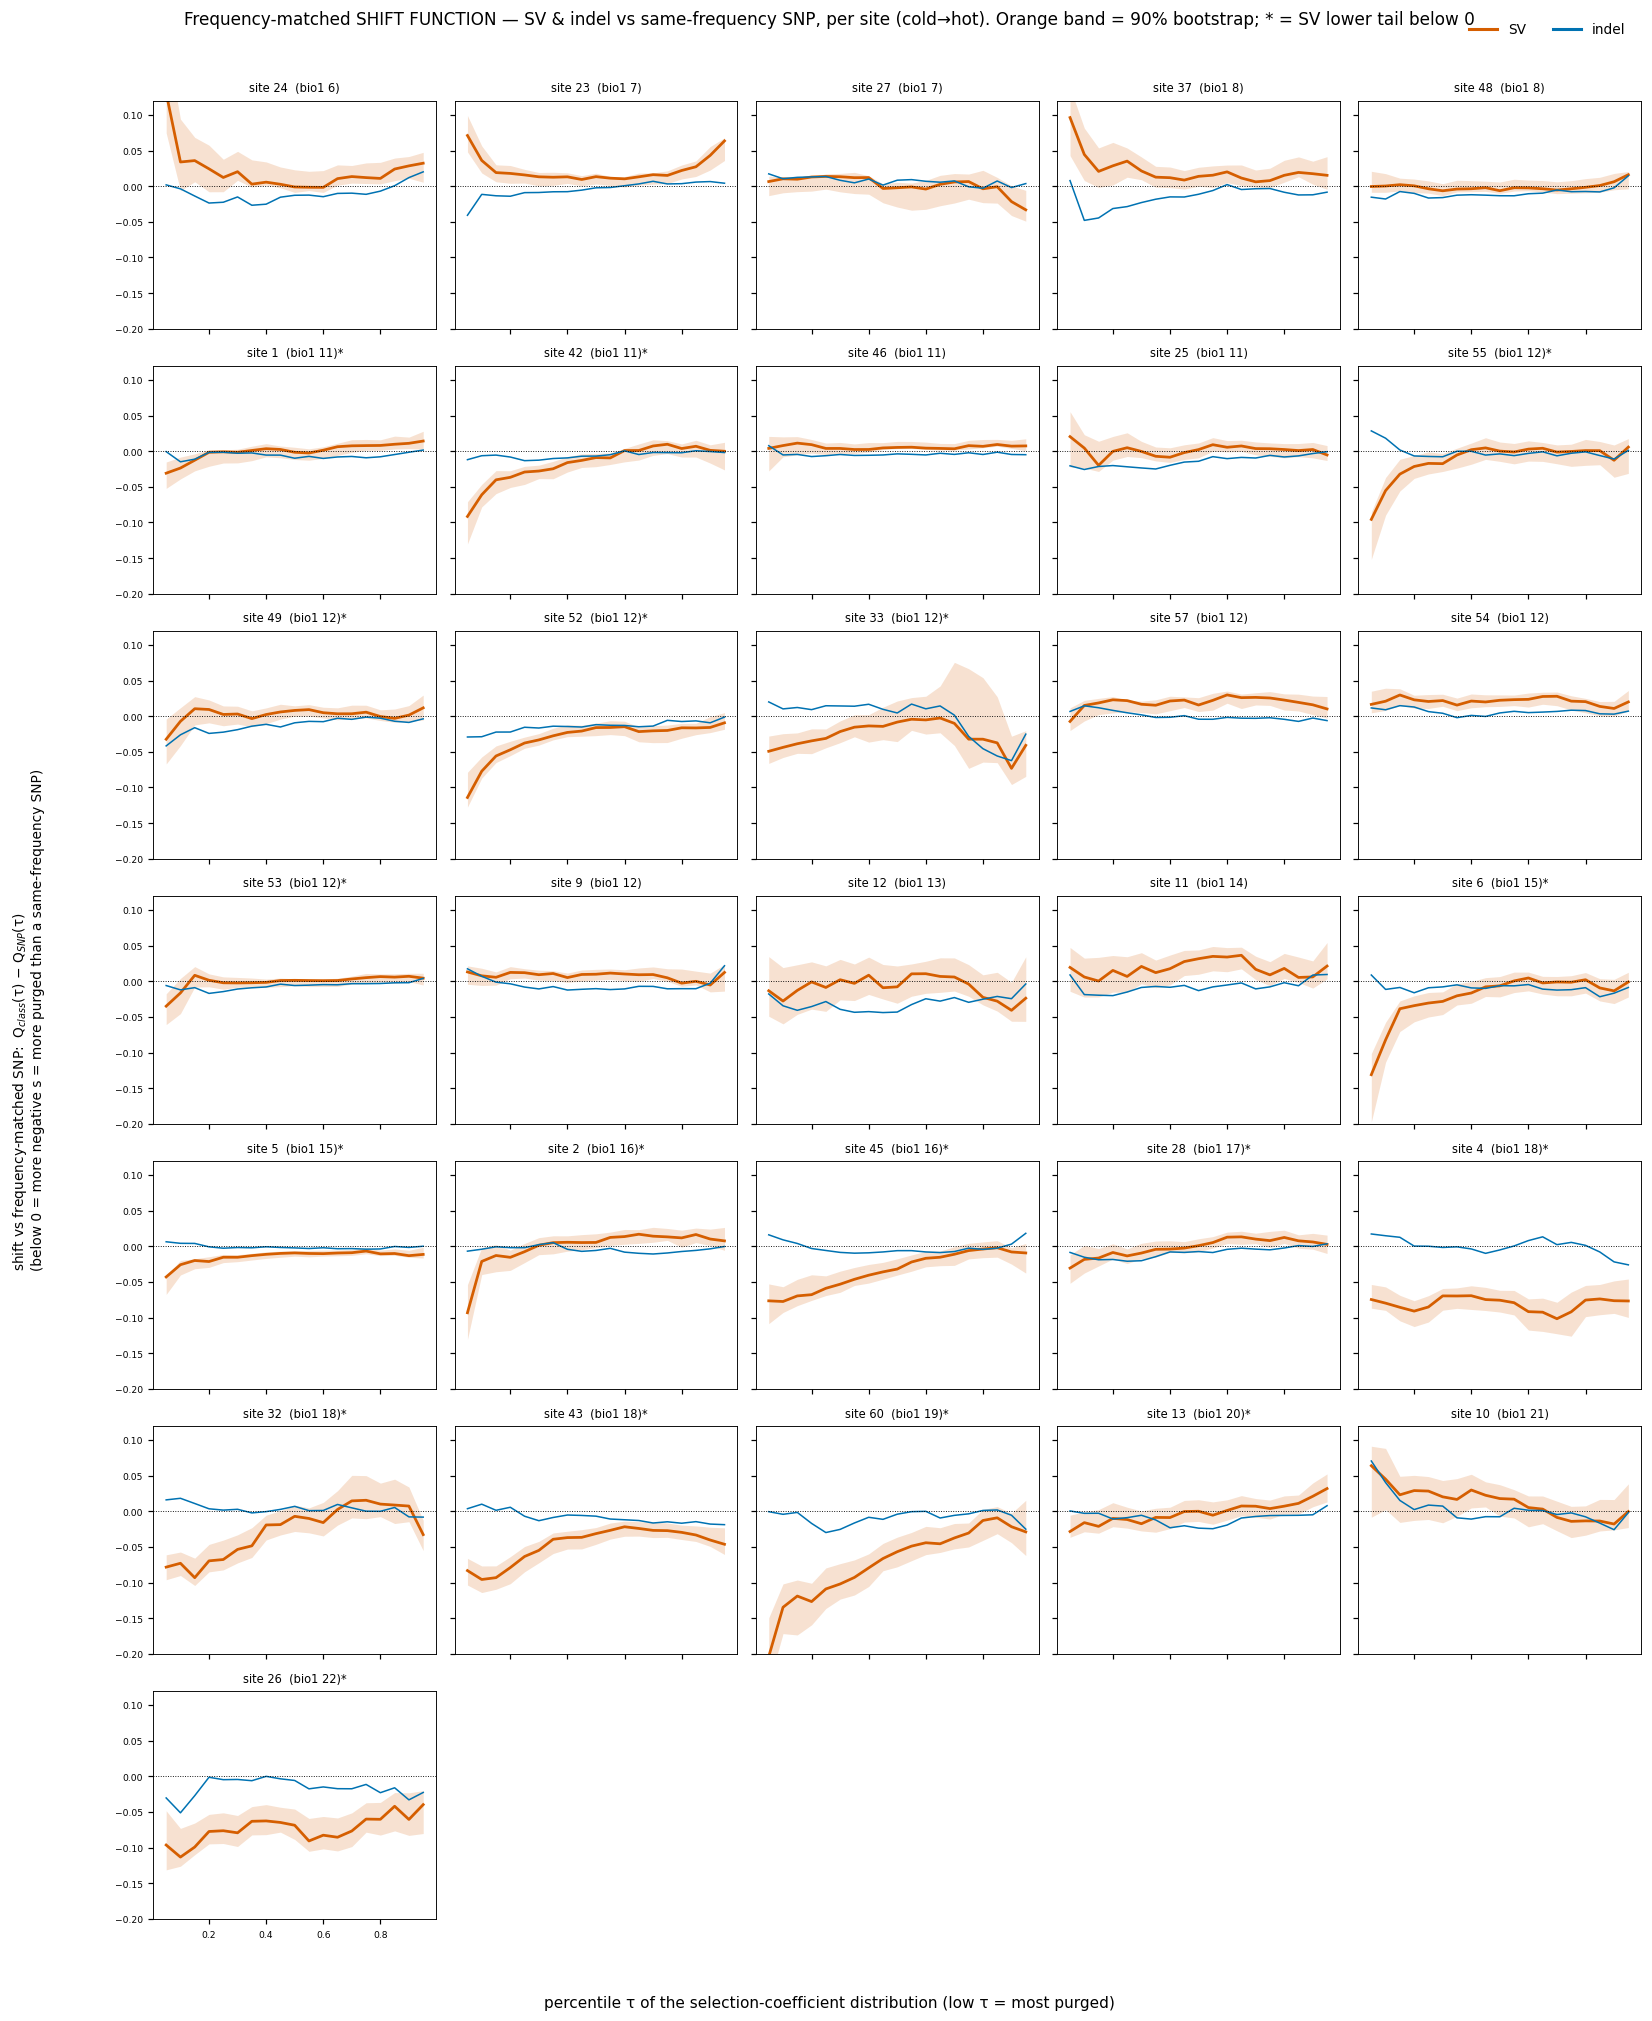

saved s_shiftfunction_by_site.png


In [2]:

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.6*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]
    sh_sv, sh_ind, lo, hi = shift_and_band(s)
    ax.fill_between(TAUS, lo, hi, color=COL["SV"], alpha=0.18, lw=0)
    ax.plot(TAUS, sh_sv,  "-", color=COL["SV"],  lw=1.8, label="SV")
    ax.plot(TAUS, sh_ind, "-", color=COL["indel"], lw=1.0, label="indel")
    ax.axhline(0, color="k", lw=0.6, ls=":")
    b1 = meta[meta.site==s].bio1.iloc[0]
    sig = "*" if (hi[:6] < 0).any() else ""     # SV lower-tail band below 0
    ax.set_title(f"site {s}  (bio1 {b1:.0f}){sig}", fontsize=7.5)
    ax.tick_params(labelsize=6)
axes[0].set_ylim(-0.20, 0.12)
fig.supxlabel("percentile τ of the selection-coefficient distribution (low τ = most purged)",
              y=0.005, fontsize=10)
fig.supylabel("shift vs frequency-matched SNP:  Q$_{class}$(τ) − Q$_{SNP}$(τ)\n"
              "(below 0 = more negative s = more purged than a same-frequency SNP)",
              x=0.004, fontsize=9)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SV","indel"]],
           loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.suptitle("Frequency-matched SHIFT FUNCTION — SV & indel vs same-frequency SNP, per site "
             "(cold→hot). Orange band = 90% bootstrap; * = SV lower tail below 0", fontsize=11, y=1.004)
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_shiftfunction_by_site.png", dpi=130, bbox_inches="tight")
plt.show(); print("saved s_shiftfunction_by_site.png")


### How to read
- **x = percentile** of the s-distribution: far left = the most *purged* variants (biggest declines),
  far right = the most *favoured*.
- **y = SV(or indel) quantile − frequency-matched-SNP quantile.** 0 = identical to a same-frequency
  SNP at that rank.
- **indel (blue) hugs 0 everywhere** — indels really are like SNPs (genuine, not an artifact).
- **SV (orange) dipping below 0 on the LEFT** = SVs have a heavier purged tail than same-frequency
  SNPs; if the orange band stays below 0 there, it's significant. A flat orange line = SVs also
  identical. This isolates the true class effect after removing the frequency confound.

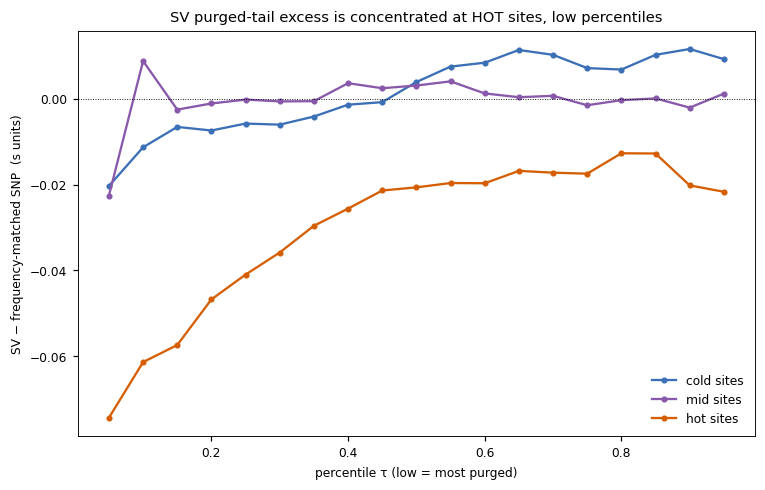

In [3]:

# pooled shift function by climate tercile (cold / mid / hot), stacking all variants in each tercile
terc = pd.qcut(meta.bio1, 3, labels=["cold","mid","hot"])
fig, ax = plt.subplots(1, 1, figsize=(7,4.5))
tcol = {"cold":"#3B6FB6","mid":"#8858AA","hot":"#D55E00"}
for t in ["cold","mid","hot"]:
    ss = meta.site[terc.values==t].tolist()
    sv = np.concatenate([npz[f"{s}_s_SV"] for s in ss]); p_sv=np.concatenate([npz[f"{s}_p0_SV"] for s in ss])
    sn = np.concatenate([npz[f"{s}_s_SNP"] for s in ss]); p_sn=np.concatenate([npz[f"{s}_p0_SNP"] for s in ss])
    m = match_to(p_sv, sn, p_sn, rng)
    ax.plot(TAUS, np.quantile(sv,TAUS)-np.quantile(m,TAUS), "-o", color=tcol[t], ms=3, label=f"{t} sites")
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("percentile τ (low = most purged)")
ax.set_ylabel("SV − frequency-matched SNP  (s units)")
ax.set_title("SV purged-tail excess is concentrated at HOT sites, low percentiles")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/s_shiftfunction_summary.png", dpi=130, bbox_inches="tight")
plt.show()


### Takeaway
Once the frequency confound is removed and we look at the *difference* rather than the overlaid
distributions:
- **indel vs SNP ≈ 0 at every percentile** — the non-SNP bulk is genuinely identical to SNPs.
- **SV vs SNP is ~0 across most percentiles but dips negative in the lower (purged) tail**, and that
  dip is **concentrated at hot sites** — the real, modest, SV-specific signal is a slightly heavier
  purged tail for SVs at warm sites, not a whole-distribution shift. (And from the ins/del split it is
  insertion-driven.) This is what the histograms couldn't show.